In [1]:
%matplotlib inline
import os
import random
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Verify imports
print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"nn.Module exists: {hasattr(nn, 'Module')}")

All libraries imported successfully!
PyTorch version: 2.6.0+cu124
nn.Module exists: True


In [2]:
# def split_dataset(source_folder, dest_folder, train_ratio=0.8, valid_ratio=0.2):
#     assert train_ratio + valid_ratio == 1.0, "Ratios must sum to 1.0"
    
#     # Create train and valid folders
#     for split in ['train', 'valid']:
#         for class_name in os.listdir(source_folder):
#             class_path = os.path.join(source_folder, class_name)
#             if not os.path.isdir(class_path):
#                 continue
#             split_class_folder = os.path.join(dest_folder, split, class_name)
#             os.makedirs(split_class_folder, exist_ok=True)
    
#     # Process each class
#     for class_name in os.listdir(source_folder):
#         class_path = os.path.join(source_folder, class_name)
#         if not os.path.isdir(class_path):
#             continue
        
#         images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
#         random.shuffle(images)
        
#         total = len(images)
#         train_end = int(total * train_ratio)
        
#         train_images = images[:train_end]
#         valid_images = images[train_end:]
        
#         def copy_images(image_list, split_type):
#             for img_name in image_list:
#                 src = os.path.join(class_path, img_name)
#                 dst = os.path.join(dest_folder, split_type, class_name, img_name)
#                 shutil.copy2(src, dst)
        
#         copy_images(train_images, 'train')
#         copy_images(valid_images, 'valid')
        
#         print(f"Processed {class_name}: {len(train_images)} train, {len(valid_images)} valid")

# # Your folders
# source_folder = '/home/aiyub/Research/rin2d/radiology_ai/Invention/dataset'           
# dest_folder = '/home/aiyub/Research/rin2d/radiology_ai/Invention/splitted'             

# split_dataset(source_folder, dest_folder)


In [13]:
# Configurations
IMAGE_SIZE = 256
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
K_NEIGHBORS = 2
BATCH_SIZE = 32
NUM_EPOCHS = 100
PATIENCE = 20
NUM_WORKERS = min(4, os.cpu_count() or 1)
TRAIN_DIR = "/home/shanin/Downloads/Preprocessed/train"
TEST_DIR = "/home/shanin/Downloads/Preprocessed/valid"
CHECKPOINT_PATH = "best_model.pth"

# Verify configurations
print(f"Device: {DEVICE}")
print(f"Train Directory: {TRAIN_DIR}")
print(f"Test : {TEST_DIR}")
print(f"Checkpoint Path: {CHECKPOINT_PATH}")
print(f"Number of Workers: {NUM_WORKERS}")

Device: cuda
Train Directory: /home/shanin/Downloads/Preprocessed/train
Test : /home/shanin/Downloads/Preprocessed/valid
Checkpoint Path: best_model.pth
Number of Workers: 4


In [3]:
# CNN-LSTM Feature Extractor
class CNNLSTM(nn.Module):
    def __init__(self):
        super(CNNLSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.lstm = nn.LSTM(input_size=128*4*4, hidden_size=512, batch_first=True)
        self.fc = nn.Linear(512, 64)
        
        # Initialize weights
        self.apply(self.init_weights)
    
    @staticmethod
    def init_weights(m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.cnn(x)
        batch_size = x.size(0)
        x = x.view(batch_size, 1, -1)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        return self.fc(x)

# Verify model definition
model = CNNLSTM()
print(model)

CNNLSTM(
  (cnn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track

In [4]:
# GNN Classifier
class FaceGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(FaceGNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)
        
        # Initialize weights
        self.apply(self.init_weights)
    
    @staticmethod
    def init_weights(m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return self.classifier(x)

# Verify model definition
num_classes = 4  # Placeholder, will be set later
gnn_model = FaceGNN(input_dim=64, hidden_dim=256, num_classes=num_classes)
print(gnn_model)

FaceGNN(
  (conv1): GCNConv(64, 256)
  (conv2): GCNConv(256, 256)
  (classifier): Linear(in_features=256, out_features=4, bias=True)
)


In [5]:
# Graph Construction
def build_knn_graph(features, k=K_NEIGHBORS):
    features = F.normalize(features, p=2, dim=1)
    features_np = features.detach().cpu().numpy()
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(features_np)
    _, indices = nn.kneighbors(features_np)
    edges = []
    for i in range(len(indices)):
        for j in indices[i]:
            if i != j:
                edges.append([i, j])
                edges.append([j, i])
    return torch.tensor(edges, dtype=torch.long).t().contiguous().to(DEVICE)

# Verify function
sample_features = torch.rand(10, 64).to(DEVICE)
edge_index = build_knn_graph(sample_features, k=2)
print(f"Edge index shape: {edge_index.shape}")

Edge index shape: torch.Size([2, 20])


In [6]:
# Dataset Class
class FaceDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        try:
            image = Image.open(self.image_paths[idx]).convert('RGB')
            label = self.labels[idx]
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Warning: Skipping corrupted image {self.image_paths[idx]}: {e}")
            return None

# Custom Collate Function
def custom_collate_fn(batch):
    batch = [item for item in batch if item is not None]
    if not batch:
        return None
    return torch.utils.data.dataloader.default_collate(batch)

# Data Loading Function
def load_data(data_dir):
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    image_paths = []
    labels = []
    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)
        img_files = [f for f in sorted(os.listdir(class_dir)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if not img_files:
            print(f"Warning: No valid images in class {class_name}")
            continue
        for img_name in img_files:
            image_paths.append(os.path.join(class_dir, img_name))
            labels.append(class_to_idx[class_name])
    if not image_paths:
        raise ValueError("No valid images found in the dataset")
    return image_paths, labels, class_to_idx

# Verify data loading
try:
    train_paths, train_labels, train_class_to_idx = load_data(TRAIN_DIR)
    test_paths, test_labels, test_class_to_idx = load_data(TEST_DIR)
    print(f"Loaded {len(train_paths)} training images, {len(test_paths)} test images")
    print(f"Training classes: {train_class_to_idx}")
    print(f"Test classes: {test_class_to_idx}")
except ValueError as e:
    print(f"Error: {e}")

Loaded 1610 training images, 400 test images
Training classes: {'amd': 0, 'cataract': 1, 'diabetes': 2, 'normal': 3}
Test classes: {'amd': 0, 'cataract': 1, 'diabetes': 2, 'normal': 3}


In [7]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),       # Add vertical flip
    transforms.RandomRotation(degrees=20),       # Increase rotation
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Slight translation
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.02),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),  # Simulate perspective changes
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create Datasets and DataLoaders
train_dataset = FaceDataset(train_paths, train_labels, train_transform)
test_dataset = FaceDataset(test_paths, test_labels, test_transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=custom_collate_fn
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=custom_collate_fn
)

# Verify DataLoader
sample_batch = next(iter(train_loader))
if sample_batch is not None:
    images, labels = sample_batch
    print(f"Sample train batch: Images shape: {images.shape}, Labels shape: {labels.shape}")
else:
    print("Warning: Sample train batch is None, check for corrupted images")

Sample train batch: Images shape: torch.Size([32, 3, 256, 256]), Labels shape: torch.Size([32])


In [ ]:
# Training Function
def train(feature_extractor, gnn, train_loader, optimizer, criterion, scaler):
    feature_extractor.train()
    gnn.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    num_batches = 0
    
    for batch in tqdm(train_loader, desc="Training"):
        if batch is None:
            continue
        images, labels = batch
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            features = feature_extractor(images)
            edge_index = build_knn_graph(features)
            logits = gnn(features, edge_index)  
            loss = criterion(logits, labels)
            preds = logits.argmax(dim=1)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        num_batches += 1
    
    accuracy = accuracy_score(all_labels, all_preds)
    return total_loss / max(num_batches, 1), accuracy

In [9]:
# Evaluation Function
def evaluate(feature_extractor, gnn, loader):
    feature_extractor.eval()
    gnn.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    num_batches = 0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            if batch is None:
                continue
            images, labels = batch
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            with torch.amp.autocast('cuda'):
                features = feature_extractor(images)
                edge_index = build_knn_graph(features)
                logits = gnn(features, edge_index)
                loss = criterion(logits, labels)
                preds = logits.argmax(dim=1)
            
            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            num_batches += 1
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    avg_loss = total_loss / max(num_batches, 1)
    
    return accuracy, precision, recall, all_labels, all_preds, avg_loss

In [10]:
# Plot Confusion Matrix
def plot_confusion_matrix(true_labels, pred_labels, class_names, save_path="confusion_matrix.png"):
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

# Plot Training Curves
def plot_training_curves(train_losses, train_accs, val_losses, val_accs, save_path="training_curves.png"):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(False)
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, 'b-', label='Train Accuracy')
    plt.plot(epochs, val_accs, 'r-', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(False)
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

In [11]:
# Initialize Models
feature_extractor = CNNLSTM().to(DEVICE)
gnn = FaceGNN(input_dim=64, hidden_dim=256, num_classes=len(train_class_to_idx)).to(DEVICE)

# Optimizer, Scheduler, Scaler, and Loss
optimizer = torch.optim.Adam([
    {'params': feature_extractor.parameters()},
    {'params': gnn.parameters()}
], lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=PATIENCE, verbose=True)
scaler = GradScaler()
criterion = nn.CrossEntropyLoss()

# Verify initialization
print("Models, optimizer, scheduler, scaler, and criterion initialized")

Models, optimizer, scheduler, scaler, and criterion initialized


/home/shanin/miniconda3/envs/shanin/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_374865/2411119824.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [14]:
# Training Loop
best_accuracy = 0
patience_counter = 0
train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train(feature_extractor, gnn, train_loader, optimizer, criterion, scaler)
    val_acc, val_precision, val_recall, val_labels, val_preds, val_loss = evaluate(feature_extractor, gnn, test_loader)
    
    # Store metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Precision: {val_precision:.4f} | Recall: {val_recall:.4f}")
    
    # Update scheduler
    scheduler.step(val_acc)
    
    # Save best model
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        patience_counter = 0
        torch.save({
            'feature_extractor': feature_extractor.state_dict(),
            'gnn': gnn.state_dict(),
            'class_to_idx': train_class_to_idx
        }, CHECKPOINT_PATH)
        print("Saved new best model")
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"Early stopping triggered after {epoch} epochs")
        break

print(f"\nTraining complete! Best Validation Accuracy: {best_accuracy:.4f}")

Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.60it/s]



Epoch 1/100
Train Loss: 1.3461 | Train Acc: 0.3820
Val Loss: 0.9366 | Val Acc: 0.5625 | Precision: 0.5408 | Recall: 0.5625
Saved new best model


Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.41it/s]



Epoch 2/100
Train Loss: 1.0656 | Train Acc: 0.5006
Val Loss: 0.9109 | Val Acc: 0.6175 | Precision: 0.6334 | Recall: 0.6175
Saved new best model


Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.41it/s]


...


Epoch 98/100
Train Loss: 0.2463 | Train Acc: 0.9124
Val Loss: 0.1193 | Val Acc: 0.9625 | Precision: 0.9652 | Recall: 0.9625


Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.97it/s]



Epoch 99/100
Train Loss: 0.2669 | Train Acc: 0.9081
Val Loss: 0.1120 | Val Acc: 0.9575 | Precision: 0.9584 | Recall: 0.9575


Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.25it/s]


Epoch 100/100
Train Loss: 0.2754 | Train Acc: 0.8963
Val Loss: 0.1500 | Val Acc: 0.9500 | Precision: 0.9546 | Recall: 0.9500

Training complete! Best Validation Accuracy: 0.9725


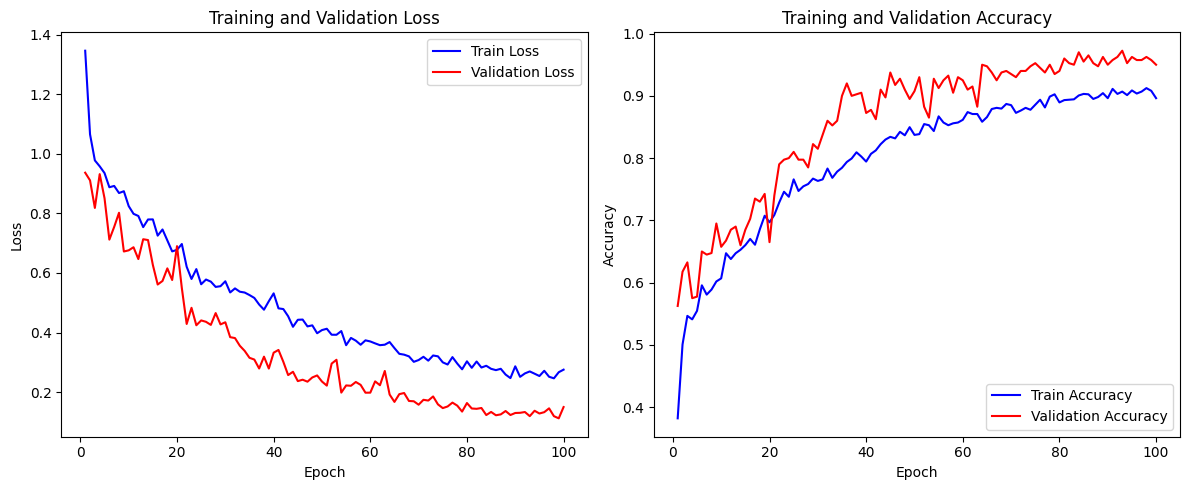

In [15]:
# Plot training and validation curves
plot_training_curves(train_losses, train_accs, val_losses, val_accs)

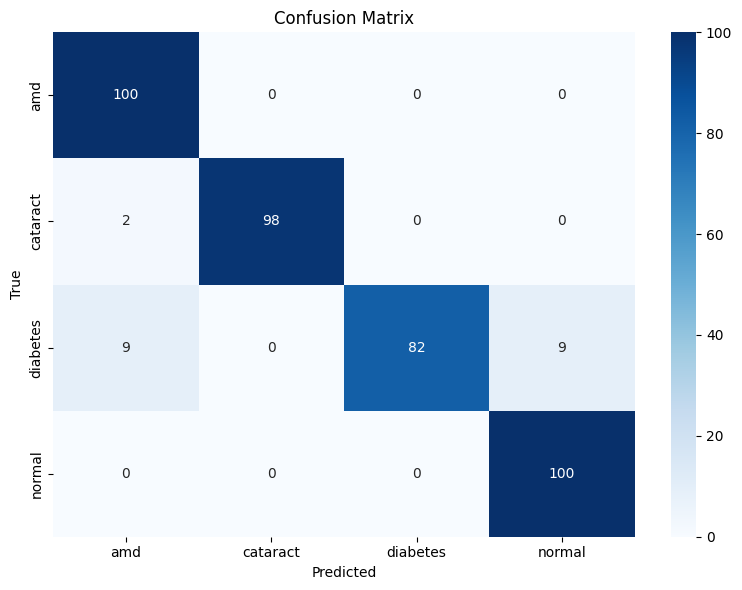

In [16]:
# Plot confusion matrix from training evaluation
class_names = [k for k, v in sorted(train_class_to_idx.items(), key=lambda x: x[1])]
plot_confusion_matrix(val_labels, val_preds, class_names)